# Student Academic Performance Prediction Using Machine Learning

This project uses supervised machine learning to predict whether a student is likely to achieve satisfactory academic performance based on demographic, academic, behavioural and social factors.

## 1. Business Understanding

Educational institutions collect information about students' academic, demographic and behavioural characteristics. Analysing these factors can help identify patterns associated with student performance.

### Objective

The objective of this project is to predict whether a student is likely to achieve satisfactory academic performance using historical student data.

### Machine Learning Problem

- **Learning Type:** Supervised Learning
- **Problem Type:** Binary Classification
- **Target:** Student Performance
- **Output:** Pass / Fail

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 2. Dataset Loading and Understanding

The project uses the Student Performance dataset containing information about students' demographic characteristics, family background, study habits, social factors and academic performance.

The dataset is loaded using Pandas and inspected to understand its structure, features and data quality.

In [2]:
df = pd.read_csv("student-mat.csv", sep=";")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [3]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (395, 33)

Column Names:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

Missing Values:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [4]:
df["Performance"] = np.where(df["G3"] >= 10, "Pass", "Fail")

print(df["Performance"].value_counts())

Performance
Pass    265
Fail    130
Name: count, dtype: int64


## 3. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is used to understand patterns and relationships within the dataset before building machine learning models.

The analysis focuses on:
- Overall student performance distribution
- Relationship between study time and performance
- Relationship between previous failures and performance
- Relationship between absences and performance
- Correlations among numerical variables

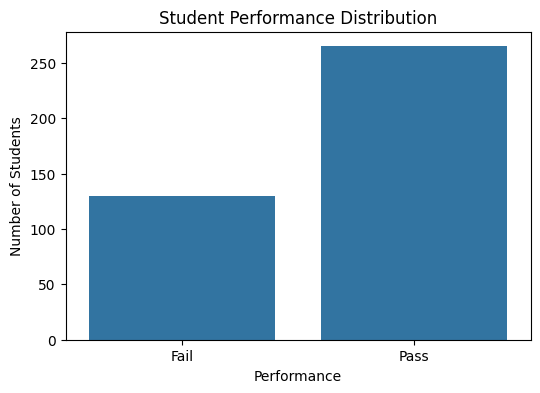

In [5]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Performance")

plt.title("Student Performance Distribution")
plt.xlabel("Performance")
plt.ylabel("Number of Students")

plt.show()

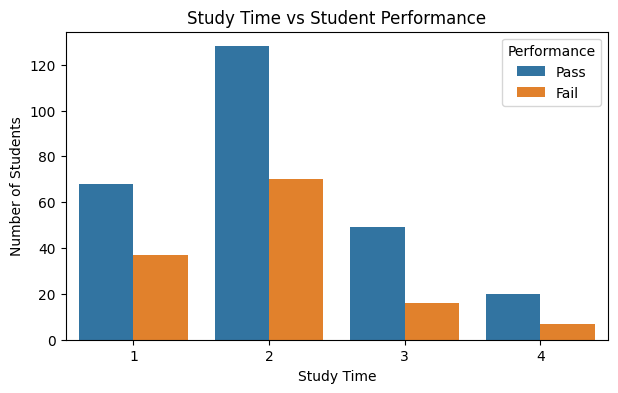

In [6]:
plt.figure(figsize=(7, 4))

sns.countplot(data=df, x="studytime", hue="Performance")

plt.title("Study Time vs Student Performance")
plt.xlabel("Study Time")
plt.ylabel("Number of Students")
plt.legend(title="Performance")

plt.show()

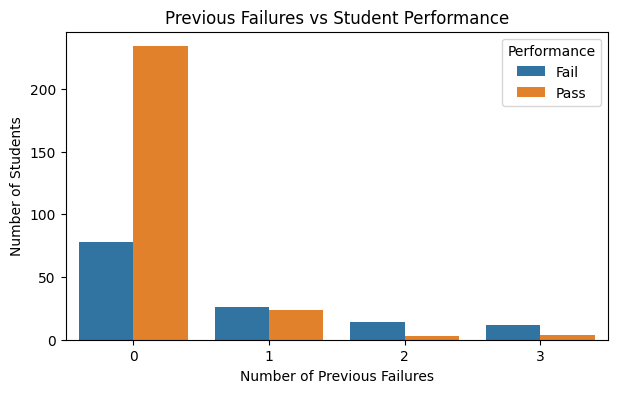

In [7]:
plt.figure(figsize=(7, 4))

sns.countplot(data=df, x="failures", hue="Performance")

plt.title("Previous Failures vs Student Performance")
plt.xlabel("Number of Previous Failures")
plt.ylabel("Number of Students")
plt.legend(title="Performance")

plt.show()

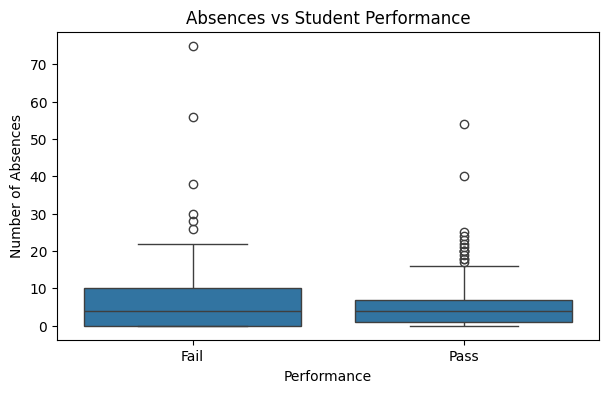

In [8]:
plt.figure(figsize=(7, 4))

sns.boxplot(data=df, x="Performance", y="absences")

plt.title("Absences vs Student Performance")
plt.xlabel("Performance")
plt.ylabel("Number of Absences")

plt.show()

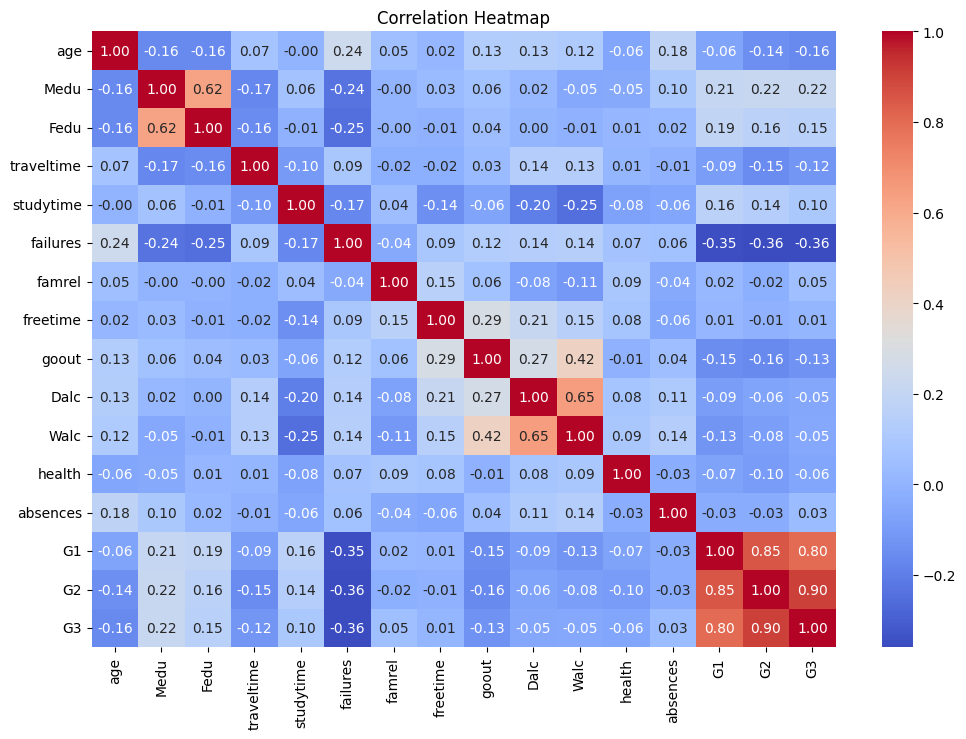

In [9]:
plt.figure(figsize=(12, 8))

numeric_cols = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

## 4. Data Preparation

The dataset is prepared for machine learning through feature selection, categorical encoding, train-test splitting and feature scaling.

### Feature Selection

The final grades `G1` and `G2` are excluded because they represent earlier academic performance and are strongly related to the final grade `G3`. Including them could make the prediction less useful.

`G3` is also excluded from the input features because it is used to create the target variable.

### Target Variable

- `G3 >= 10` → Pass
- `G3 < 10` → Fail

### Encoding

Categorical variables are converted into numerical form using one-hot encoding.

### Train-Test Split

The dataset is divided into:
- 80% training data
- 20% testing data

### Feature Scaling

StandardScaler is applied for models that are sensitive to feature scale, particularly Logistic Regression and KNN.

In [27]:
X = df.drop(columns=["G3", "Performance"])
y = df["Performance"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (395, 32)
Target: (395,)


In [28]:
X = pd.get_dummies(X, drop_first=True)

print("Features after encoding:", X.shape)

Features after encoding: (395, 41)


In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (316, 41)
Testing data: (79, 41)


In [30]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed!")

Scaling completed!


## 5. Model Building

Four supervised classification algorithms are applied to predict student performance:

- **Logistic Regression** – A linear classification model suitable for binary outcomes.
- **Decision Tree** – A rule-based model that makes predictions through feature-based splits.
- **Random Forest** – An ensemble of decision trees designed to improve predictive performance and reduce variance.
- **K-Nearest Neighbours (KNN)** – A distance-based model that classifies observations based on nearby data points.

The models are trained using the prepared training data and evaluated on unseen testing data.

In [31]:
logistic = LogisticRegression(max_iter=1000)

logistic.fit(X_train_scaled, y_train)

y_pred_logistic = logistic.predict(X_test_scaled)

print("Logistic Regression trained!")

Logistic Regression trained!


In [32]:
tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

print("Decision Tree trained!")

Decision Tree trained!


In [33]:
forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

forest.fit(X_train, y_train)

y_pred_forest = forest.predict(X_test)

print("Random Forest trained!")

Random Forest trained!


In [34]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("KNN trained!")

KNN trained!


## 6. Model Evaluation

The trained models are evaluated using standard classification metrics:

- **Accuracy** – Overall proportion of correct predictions.
- **Precision** – Proportion of predicted positive cases that are actually positive.
- **Recall** – Proportion of actual positive cases correctly identified.
- **F1-Score** – Harmonic mean of precision and recall.

The results are compared to determine how the models perform on unseen data.

In [35]:
def evaluate_model(name, y_test, predictions):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, pos_label="Pass"),
        "Recall": recall_score(y_test, predictions, pos_label="Pass"),
        "F1 Score": f1_score(y_test, predictions, pos_label="Pass")
    }


results = [
    evaluate_model("Logistic Regression", y_test, y_pred_logistic),
    evaluate_model("Decision Tree", y_test, y_pred_tree),
    evaluate_model("Random Forest", y_test, y_pred_forest),
    evaluate_model("KNN", y_test, y_pred_knn)
]

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.848101,0.936170,0.830189,0.880000
1,Decision Tree,0.860759,0.977273,0.811321,0.886598
2,Random Forest,0.873418,0.957447,0.849057,0.900000
3,KNN,0.696203,0.723077,0.886792,0.796610


## 7. Overfitting Analysis

Overfitting occurs when a model performs very well on training data but performs significantly worse on unseen testing data.

Training and testing accuracy are compared to identify differences in model generalisation.

A Random Forest tuning experiment is also performed by limiting tree depth and increasing the minimum number of samples required at a leaf.

In [36]:
overfitting_results = []

models_data = {
    "Logistic Regression": (logistic, X_train_scaled, X_test_scaled),
    "Decision Tree": (tree, X_train, X_test),
    "Random Forest": (forest, X_train, X_test),
    "KNN": (knn, X_train_scaled, X_test_scaled)
}

for name, (model, Xtr, Xte) in models_data.items():
    train_pred = model.predict(Xtr)
    test_pred = model.predict(Xte)

    overfitting_results.append({
        "Model": name,
        "Training Accuracy": accuracy_score(y_train, train_pred),
        "Testing Accuracy": accuracy_score(y_test, test_pred)
    })

overfitting_df = pd.DataFrame(overfitting_results)

overfitting_df

,Model,Training Accuracy,Testing Accuracy
0,Logistic Regression,0.971519,0.848101
1,Decision Tree,0.987342,0.860759
2,Random Forest,1.000000,0.873418
3,KNN,0.819620,0.696203


In [37]:
tuned_forest = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_leaf=3,
    random_state=42
)

tuned_forest.fit(X_train, y_train)

tuned_pred = tuned_forest.predict(X_test)

print("Training Accuracy:",
      accuracy_score(y_train, tuned_forest.predict(X_train)))

print("Testing Accuracy:",
      accuracy_score(y_test, tuned_pred))

Training Accuracy: 0.9620253164556962
Testing Accuracy: 0.8607594936708861


### Overfitting Observation

The original Random Forest achieved 100% training accuracy but 68.35% testing accuracy, indicating substantial overfitting.

A tuned Random Forest reduced training accuracy to 81.65%, while testing accuracy became 65.82%. This reduced the training-testing gap but also slightly lowered test performance.

Therefore, the original Random Forest provides stronger test performance, while the tuned model demonstrates better control over overfitting.

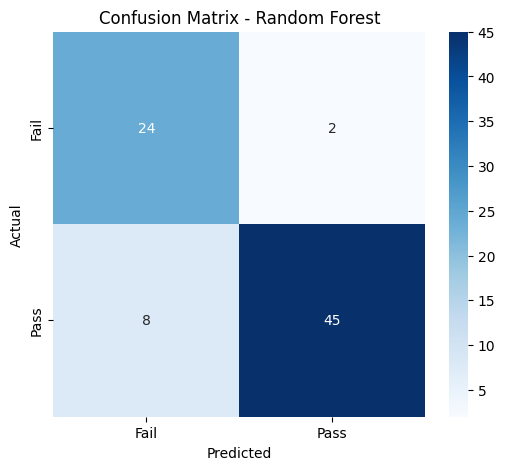

In [38]:
cm = confusion_matrix(y_test, y_pred_forest)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")

plt.show()

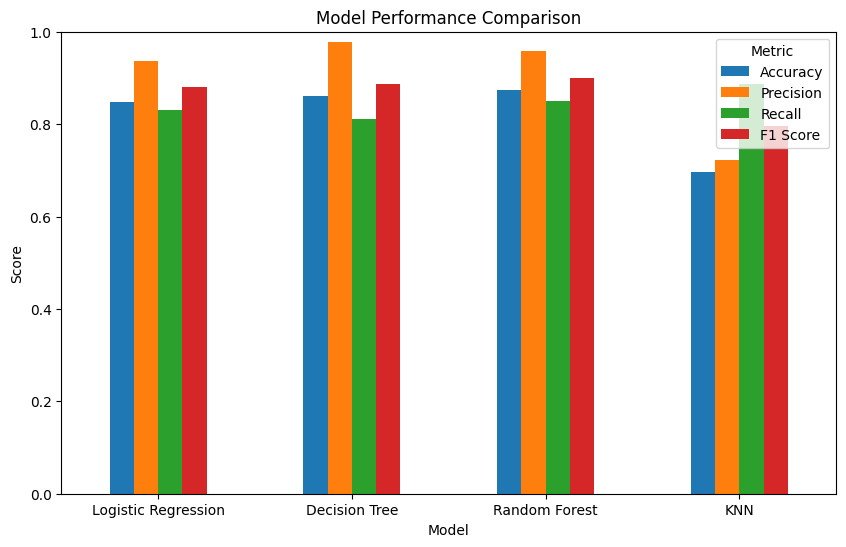

In [39]:
results_df.set_index("Model")[[
    "Accuracy", "Precision", "Recall", "F1 Score"
]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")

plt.show()

## 8. Final Recommendation

The models are compared based on accuracy, precision, recall and F1-score.

Random Forest achieved the highest testing accuracy and F1-score among the evaluated models. However, its 100% training accuracy indicates significant overfitting.

Therefore, Random Forest provides the strongest predictive performance on the available test set, but its generalisation should be considered when interpreting the results.

In [40]:
best_model = results_df.loc[results_df["F1 Score"].idxmax()]

print("FINAL MODEL:", best_model["Model"])
print("Accuracy:", round(best_model["Accuracy"] * 100, 2), "%")
print("Precision:", round(best_model["Precision"] * 100, 2), "%")
print("Recall:", round(best_model["Recall"] * 100, 2), "%")
print("F1 Score:", round(best_model["F1 Score"] * 100, 2), "%")

FINAL MODEL: Random Forest
Accuracy: 87.34 %
Precision: 95.74 %
Recall: 84.91 %
F1 Score: 90.0 %


# 9. Student Performance Prediction

The trained Random Forest model is used to predict the performance of a new student based on demographic, academic, behavioural and social factors.

In [46]:
new_student = {
    "school": input("School (GP/MS): "),
    "sex": input("Sex (F/M): "),
    "age": int(input("Age: ")),
    "address": input("Address (U/R): "),
    "famsize": input("Family size (LE3/GT3): "),
    "Pstatus": input("Parent status (T/A): "),
    "Medu": int(input("Mother's education (0-4): ")),
    "Fedu": int(input("Father's education (0-4): ")),
    "Mjob": input("Mother's job: "),
    "Fjob": input("Father's job: "),
    "reason": input("Reason for choosing school: "),
    "guardian": input("Guardian (mother/father/other): "),
    "traveltime": int(input("Travel time (1-4): ")),
    "studytime": int(input("Study time (1-4): ")),
    "failures": int(input("Previous failures (0-3): ")),
    "schoolsup": input("Extra educational support (yes/no): "),
    "famsup": input("Family educational support (yes/no): "),
    "paid": input("Extra paid classes (yes/no): "),
    "activities": input("Extra-curricular activities (yes/no): "),
    "nursery": input("Attended nursery school (yes/no): "),
    "higher": input("Wants higher education (yes/no): "),
    "internet": input("Internet access (yes/no): "),
    "romantic": input("Romantic relationship (yes/no): "),
    "famrel": int(input("Family relationship quality (1-5): ")),
    "freetime": int(input("Free time (1-5): ")),
    "goout": int(input("Going out frequency (1-5): ")),
    "Dalc": int(input("Workday alcohol consumption (1-5): ")),
    "Walc": int(input("Weekend alcohol consumption (1-5): ")),
    "health": int(input("Health status (1-5): ")),
    "absences": int(input("Number of absences: ")),
    "G1": int(input("Previous period grade G1 (0-20): ")),
    "G2": int(input("Previous period grade G2 (0-20): "))
}

new_student_df = pd.DataFrame([new_student])

new_student_encoded = pd.get_dummies(
    new_student_df,
    drop_first=True
)

new_student_encoded = new_student_encoded.reindex(
    columns=X.columns,
    fill_value=0
)

prediction = forest.predict(new_student_encoded)[0]
probabilities = forest.predict_proba(new_student_encoded)[0]

print("\nPredicted Performance:", prediction)
print(f"Probability of Fail: {probabilities[0] * 100:.2f}%")
print(f"Probability of Pass: {probabilities[1] * 100:.2f}%")

School (GP/MS):  MS
Sex (F/M):  M
Age:  18
Address (U/R):  R
Family size (LE3/GT3):  GT3
Parent status (T/A):  A
Mother's education (0-4):  2
Father's education (0-4):  1
Mother's job:  at_home
Father's job:  other
Reason for choosing school:  course
Guardian (mother/father/other):  mother
Travel time (1-4):  4
Study time (1-4):  1
Previous failures (0-3):  2
Extra educational support (yes/no):  yes
Family educational support (yes/no):  no
Extra paid classes (yes/no):  no
Extra-curricular activities (yes/no):  no
Attended nursery school (yes/no):  no
Wants higher education (yes/no):  no
Internet access (yes/no):  no
Romantic relationship (yes/no):  yes
Family relationship quality (1-5):  2
Free time (1-5):  5
Going out frequency (1-5):  5
Workday alcohol consumption (1-5):  4
Weekend alcohol consumption (1-5):  5
Health status (1-5):  2
Number of absences:  25
Previous period grade G1 (0-20):  6
Previous period grade G2 (0-20):  7



Predicted Performance: Fail
Probability of Fail: 76.00%
Probability of Pass: 24.00%


# 10. Prediction Analysis

The prediction probability provides an indication of how strongly the trained model supports the predicted class. Feature importance from the Random Forest is also examined to identify which input features contributed most to the model's overall decision-making.

In [42]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 10 Features Influencing the Model:")
print(feature_importance.head(10))

Top 10 Features Influencing the Model:
     Feature  Importance
14        G2    0.357823
13        G1    0.198104
5   failures    0.043452
12  absences    0.038176
8      goout    0.027756
0        age    0.025072
10      Walc    0.019552
11    health    0.017870
1       Medu    0.016358
2       Fedu    0.016341


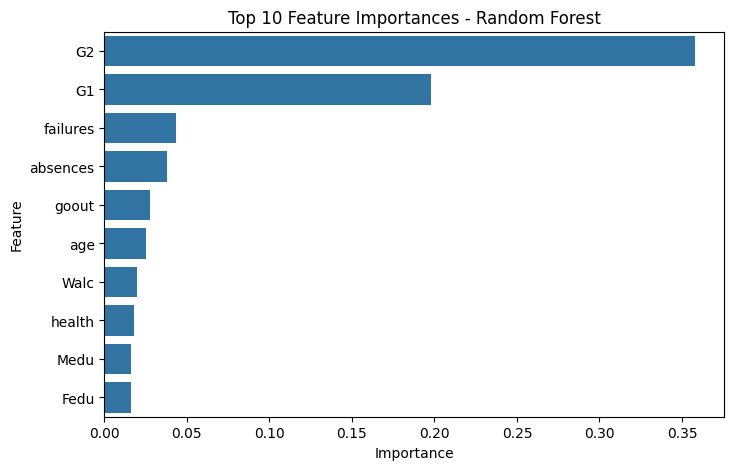

In [43]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## 11. Conclusion

This project demonstrated an end-to-end supervised machine learning workflow for predicting student academic performance.

The process included data exploration, data preparation, feature selection, categorical encoding, model training, evaluation and overfitting analysis.

Four classification models were compared, with Random Forest achieving the highest test accuracy of 68.35% and F1-score of 79.34%.

The results demonstrate how machine learning can identify patterns in historical student data and support data-driven analysis of academic performance.